In [291]:
import asyncio
from xxlimited_35 import Null

import aiohttp
import numpy as np
import pandas as pd
import random
import logging
from fake_useragent import UserAgent
import pandas as pd
from fontTools.cu2qu.cu2qu import NAN

import matplotlib.pyplot as plt
from fontTools.misc.cython import returns
import seaborn as sns

import geopandas as gpd
from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter
from openpyxl.styles.builtins import title

In [2]:
res = pd.read_excel('PR1.xlsx', index_col='№ п/п')
res.head()

,Наименование / ФИО,Тип субъекта,Категория,ОГРН,ИНН,Основной вид деятельности,Регион,Район,Город,Населенный пункт,...,Дата исключения из реестра,Телефон,E-mail,WWW,Наличие лицензий,"Наличие заключенных договоров, контрактов","Производство инновационной, высокотехнологичной продукции",Участие в программах партнерства,Является социальным предприятием,Среднесписочная численность работников за предшествующий календарный год
№ п/п,,,,,,,,,,,,,,,,,,,,,
1,""" МЕГАПОЛИС "" ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВ...",Юридическое лицо,Не является субъектом МСП,1027800523376,7801190028,41.2 Строительство жилых и нежилых зданий,78 - г.Санкт-Петербург,NaN,NaN,NaN,...,10.10.2021,NaN,NaN,NaN,Нет,Нет,Нет,Нет,Нет,NaN
2,""" СТАЛЬИНВЕСТСТРОЙ "" ОБЩЕСТВО С ОГРАНИЧЕННОЙ О...",Юридическое лицо,Не является субъектом МСП,1037800033545,7801227976,41.20 Строительство жилых и нежилых зданий,78 - г.Санкт-Петербург,NaN,NaN,NaN,...,10.08.2018,NaN,NaN,NaN,Нет,Нет,Нет,Нет,Нет,NaN
3,""" СТРОЙТЕХНИКА - М "" ОБЩЕСТВО С ОГРАНИЧЕННОЙ О...",Юридическое лицо,Не является субъектом МСП,1025204418293,5263039399,41.20 Строительство жилых и нежилых зданий,52 - Нижегородская область,NaN,г Нижний Новгород,NaN,...,10.07.2022,NaN,NaN,NaN,Нет,Нет,Нет,Нет,Нет,NaN
4,"""БАЗИС"" ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ",Юридическое лицо,Микропредприятие,1025204411682,5263025484,41.20 Строительство жилых и нежилых зданий,52 - Нижегородская область,NaN,г Нижний Новгород,NaN,...,NaN,NaN,NaN,NaN,Нет,Нет,Нет,Нет,Нет,1.0
5,"""БЕЛАГ"" ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ",Юридическое лицо,Не является субъектом МСП,1037800039276,7801123215,41.20 Строительство жилых и нежилых зданий,78 - г.Санкт-Петербург,NaN,NaN,NaN,...,10.07.2021,NaN,NaN,NaN,Нет,Нет,Нет,Нет,Нет,NaN


In [3]:
res.info()

<class 'pandas.DataFrame'>
RangeIndex: 603520 entries, 1 to 603520
Data columns (total 22 columns):
 #   Column                                                                    Non-Null Count   Dtype  
---  ------                                                                    --------------   -----  
 0   Наименование / ФИО                                                        603520 non-null  str    
 1   Тип субъекта                                                              603520 non-null  str    
 2   Категория                                                                 603520 non-null  str    
 3   ОГРН                                                                      603520 non-null  int64  
 4   ИНН                                                                       603520 non-null  int64  
 5   Основной вид деятельности                                                 603520 non-null  str    
 6   Регион                                                         

In [4]:
res.shape

(603520, 22)

In [5]:
df_filtered = res[(res['Тип субъекта'] == 'Юридическое лицо') & (res['Основной вид деятельности'] == '41.20 Строительство жилых и нежилых зданий') & (res['Категория'].isin(['Малое предприятие','Среднее предприятие']))]
df_filtered.head()

,Наименование / ФИО,Тип субъекта,Категория,ОГРН,ИНН,Основной вид деятельности,Регион,Район,Город,Населенный пункт,...,Дата исключения из реестра,Телефон,E-mail,WWW,Наличие лицензий,"Наличие заключенных договоров, контрактов","Производство инновационной, высокотехнологичной продукции",Участие в программах партнерства,Является социальным предприятием,Среднесписочная численность работников за предшествующий календарный год
№ п/п,,,,,,,,,,,,,,,,,,,,,
20,"""КОРПОРАЦИЯ ВИТ"" (ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕ...",Юридическое лицо,Малое предприятие,1025004907080,5038038838,41.20 Строительство жилых и нежилых зданий,50 - Московская область,Пушкино г,NaN,NaN,...,NaN,NaN,NaN,NaN,Нет,Нет,Нет,Нет,Нет,36.0
52,"""ХОЗРАСЧЕТНАЯ СТРОИТЕЛЬНО-ТЕХНОЛОГИЧЕСКАЯ ФИРМ...",Юридическое лицо,Среднее предприятие,1025007270551,5027006369,41.20 Строительство жилых и нежилых зданий,50 - Московская область,NaN,г Дзержинский,NaN,...,NaN,NaN,NaN,NaN,Да,Нет,Нет,Нет,Нет,201.0
4653,"АКЦИОНЕРНОЕ ОБЩЕСТВО ""777""",Юридическое лицо,Малое предприятие,1021400692048,1414006922,41.20 Строительство жилых и нежилых зданий,77 - г.Москва,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,Да,Нет,Нет,Нет,Нет,35.0
4668,"АКЦИОНЕРНОЕ ОБЩЕСТВО ""АГРОТЕХИМПОРТ""",Юридическое лицо,Малое предприятие,1043301806415,3327332190,41.20 Строительство жилых и нежилых зданий,33 - Владимирская область,NaN,г Владимир,NaN,...,NaN,NaN,NaN,NaN,Да,Нет,Нет,Нет,Нет,52.0
4674,"АКЦИОНЕРНОЕ ОБЩЕСТВО ""АКС""",Юридическое лицо,Малое предприятие,1027807999988,7816061297,41.20 Строительство жилых и нежилых зданий,78 - г.Санкт-Петербург,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,Да,Нет,Нет,Нет,Нет,21.0


In [9]:
df_filtered.shape

(8927, 22)

In [36]:
logging.basicConfig(level=logging.INFO, format='%(levelname)s: %(message)s', force=True)
ua = UserAgent()

async def fetch_revenue(session, inn, semaphore):
    url = f"https://bo.nalog.gov.ru/advanced-search/organizations/search?query={inn}&page=0"

    async with semaphore:
        await asyncio.sleep(random.uniform(0.5, 1.5))

        headers = {
            "User-Agent": ua.random,
            "Accept": "application/json, text/plain, */*",
            "Accept-Language": "ru-RU,ru;q=0.9",
            "Referer": "https://bo.nalog.gov.ru/"
        }

        try:
            async with session.get(url, headers=headers, ssl=False) as resp:
                if resp.status == 429:
                    logging.warning("Слишком много запросов")
                    return [{"inn": inn, "status": "Слишком много запросов"}]
                if resp.status != 200:
                    return [{"inn": inn, "status": resp.status}]

                company = await resp.json()
                if not company.get("content"):
                    return [{"inn": inn, "status": "Компания не найдена"}]

                org_id = company["content"][0].get("id")
                if not org_id:
                    return [{"inn": inn, "status": "ID компании не найден"}]

            await asyncio.sleep(random.uniform(0.3, 0.8))
            headers['Referer'] = url

            final_url = f"https://bo.nalog.gov.ru/nbo/organizations/{org_id}/bfo/"

            company_results = []

            async with session.get(final_url, headers= headers, ssl=False) as resp:
                if resp.status == 429:
                    logging.warning("Слишком много запросов")
                    return [{"inn": inn, "status": "Слишком много запросов"}]
                if resp.status != 200:
                    return [{"inn": inn, "status": resp.status}]

                records = await resp.json()

                for record in records:
                    period = record.get('period')

                    corrections = record.get('typeCorrections')
                    if not corrections:
                        continue

                    correction = corrections[0].get('correction', {})
                    balance = correction.get('balance', {})
                    fin_res = correction.get('financialResult', {})

                    cur1150 = balance.get('current1150') #Основные средства за текущий год
                    prev1150 = balance.get('previous1150') #Основные средства за предыдущий год

                    profit_before_tax = fin_res.get('current2300') #Прибыль до налогооблажения
                    interest_paid = fin_res.get('current2330') #Проценты к уплате

                    revenue = fin_res.get('current2110') #выручка
                    cogs = fin_res.get('current2120') #Себестоимость
                    comm_exp = fin_res.get('current2210') #Коммерческие расходы
                    mgmt_exp = fin_res.get('current2220') #Управленческие расходы
                    other_income = fin_res.get("current2340") #Прочие доходы
                    other_exp = fin_res.get("current2350") #Прочие расходы
                    taxes = fin_res.get("current2410") #Налог на прибыль
                    net_profit = fin_res.get('current2400') #Чистая прибыль

                    company_results.append({
                        'inn': inn,
                        'status': 'OK',
                        'year': period,
                        'cur1150': cur1150,
                        'prev1150': prev1150,
                        'profit_before_tax': profit_before_tax,
                        'interest_paid': interest_paid,
                        'revenue': revenue,
                        'cogs': cogs,
                        'comm_exp': comm_exp,
                        'mgmt_exp': mgmt_exp,
                        'other_income': other_income,
                        'other_exp': other_exp,
                        'taxes': taxes,
                        'net_profit': net_profit,
                    })

                return company_results if len(company_results) > 0 else [{}]

        except Exception as e:
            return [{"inn": inn, "status": f"Ошибка: {e}"}]

In [37]:
inns = df_filtered['ИНН'].tolist()

results = []

semaphore = asyncio.Semaphore(15)

async with aiohttp.ClientSession() as session:
    tasks = [fetch_revenue(session, inn, semaphore) for inn in inns]

    for i, res in enumerate(asyncio.as_completed(tasks)):
        result = await res
        results += result
        if (i + 1) % 500 == 0:
            logging.info(f"Обработано {i + 1} из {len(inns)}...")

results_df = pd.DataFrame(results)
results_df.to_csv("revenues_detailed_output.csv", index=False, encoding="utf-8-sig")
logging.info("Готово! Данные сохранены")

INFO: Обработано 500 из 8927...
INFO: Обработано 1000 из 8927...
INFO: Обработано 1500 из 8927...
INFO: Обработано 2000 из 8927...
INFO: Обработано 2500 из 8927...
INFO: Обработано 3000 из 8927...
INFO: Обработано 3500 из 8927...
INFO: Обработано 4000 из 8927...
INFO: Обработано 4500 из 8927...
INFO: Обработано 5000 из 8927...
INFO: Обработано 5500 из 8927...
INFO: Обработано 6000 из 8927...
INFO: Обработано 6500 из 8927...
INFO: Обработано 7000 из 8927...
INFO: Обработано 7500 из 8927...
INFO: Обработано 8000 из 8927...
INFO: Обработано 8500 из 8927...
INFO: Готово! Данные сохранены


In [ ]:
results_df['status'].value_counts()

In [ ]:
results_df.info()

In [322]:
results_df = pd.read_csv('revenues_detailed_output_filtered.csv')

In [323]:
df_pivot = results_df.set_index(['inn','year'])['net_profit'].unstack()
df_pivot.sample(5)

year,2021,2022,2023,2024,2025
inn,,,,,
2636036863,834.0,785.0,895.0,1103.0,1996.0
7716161259,943.0,2195.0,7.0,4414.0,9057.0
1435291075,-5589.0,4023.0,5652.0,585.0,675.0
7604133119,29895.0,4127.0,-40642.0,-50608.0,NaN
7734381698,1495.0,1127.0,939.0,107.0,-113.0


In [195]:
def gen_diff(df: pd.DataFrame, start_year: int, end_year: int):
    st = df[start_year]
    en = df[end_year]

    rost = np.where((en != 0), ((st-en)/en.abs()) * 100, np.nan)
    return rost[~np.isnan(rost)]

In [237]:
def slise(df):
    lower_bound = np.percentile(df, 1)
    upper_bound = np.percentile(df, 99)

    df = df[(df >= lower_bound) & (df <= upper_bound)]
    return df

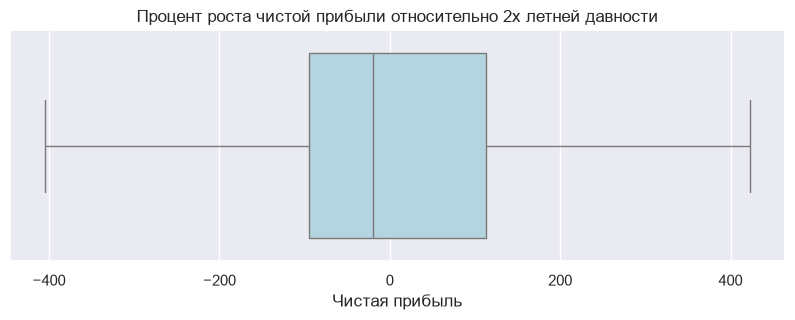

In [328]:
sns.set_theme(style='darkgrid')

plt.figure(figsize=(10, 3))

sns.boxplot(
    x=gen_diff(df_pivot, start_year=2025, end_year=2023),
    color='lightblue',
    showfliers=False,
)

plt.title('Процент роста чистой прибыли относительно 2х летней давности')
plt.xlabel('Чистая прибыль')
plt.show()

Мы посроили box plot для того, что бы посмотреть распределение роста чистой прибыли отностиельно 2х летней давности (с 2025 года).
Как видно по графику среднее значение смещено левее нуля, что означает, что в среднем чистая прибыль уходила в минус. Закрашеная область показывает 50% значений. Она находится в области нуля (даже немного смещена вправо).
Налево и направо уходят линии, равные 1.5 межквартильных размахов. За ними находятся выбросы. Я не стал показывать их на графике, так как из за этого он сильно сжимается. Но как видно 50% значений находятся в пределах от -100 до 100.

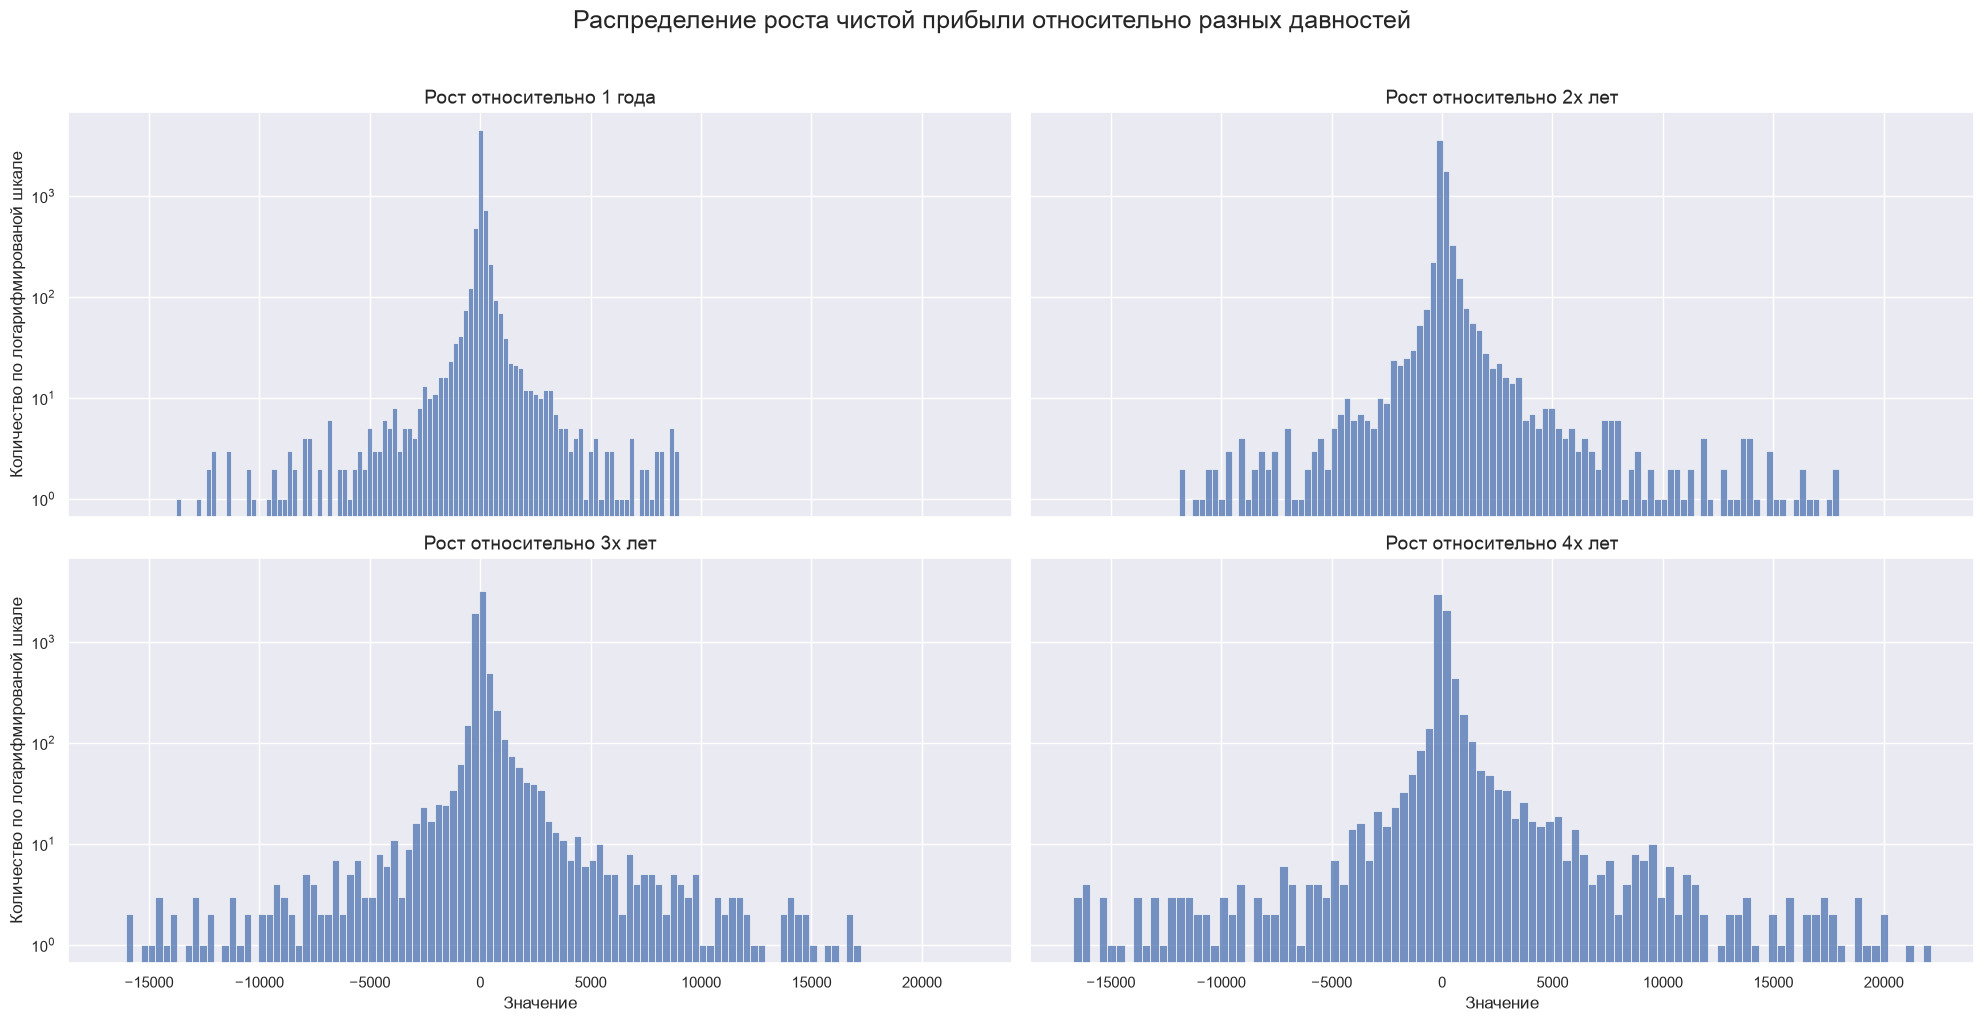

In [334]:
sns.set_theme(style="darkgrid")

fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(20, 10), sharex=True, sharey=True)

# Ваш код фильтрации данных
filtered_data1 = slise(gen_diff(df_pivot, start_year=2025, end_year=2024))
filtered_data2 = slise(gen_diff(df_pivot, start_year=2025, end_year=2023))
filtered_data3 = slise(gen_diff(df_pivot, start_year=2025, end_year=2022))
filtered_data4 = slise(gen_diff(df_pivot, start_year=2025, end_year=2021))

sns.histplot(x=filtered_data1, bins=100, ax=ax[0][0])
ax[0][0].set_title('Рост относительно 1 года', fontsize=14)

sns.histplot(x=filtered_data2, bins=100, ax=ax[0][1])
ax[0][1].set_title('Рост относительно 2х лет', fontsize=14)

sns.histplot(x=filtered_data3, bins=100, ax=ax[1][0])
ax[1][0].set_title('Рост относительно 3х лет', fontsize=14)

sns.histplot(x=filtered_data4, bins=100, ax=ax[1][1])
ax[1][1].set_title('Рост относительно 4х лет', fontsize=14)

for axis in ax.flat:
    axis.set_yscale('log')
    axis.set_xlabel('Значение', fontsize=12)
    axis.set_ylabel('Количество по логарифмированой шкале', fontsize=12)

fig.suptitle('Распределение роста чистой прибыли относительно разных давностей', fontsize=18, y=1.02)

plt.tight_layout()
plt.show()

Я построил 4 графика (гистограммы) с общими кординатами по обеим осям, для того, что бы сравнить как менялся рост прибыли относительно разных промежутков. Что бы графики не сжимались я устранил выбросы (выбросил значения меньше 1 квартиля и больше 99 квартиля). Как видно по графикам, во всех случаях значения распределялись около нуля, однако основная (самая длинная) линия все же находится левее нуля, а значит в большинстве компаний замечается убыток, относительно х летней давности.

<Axes: >

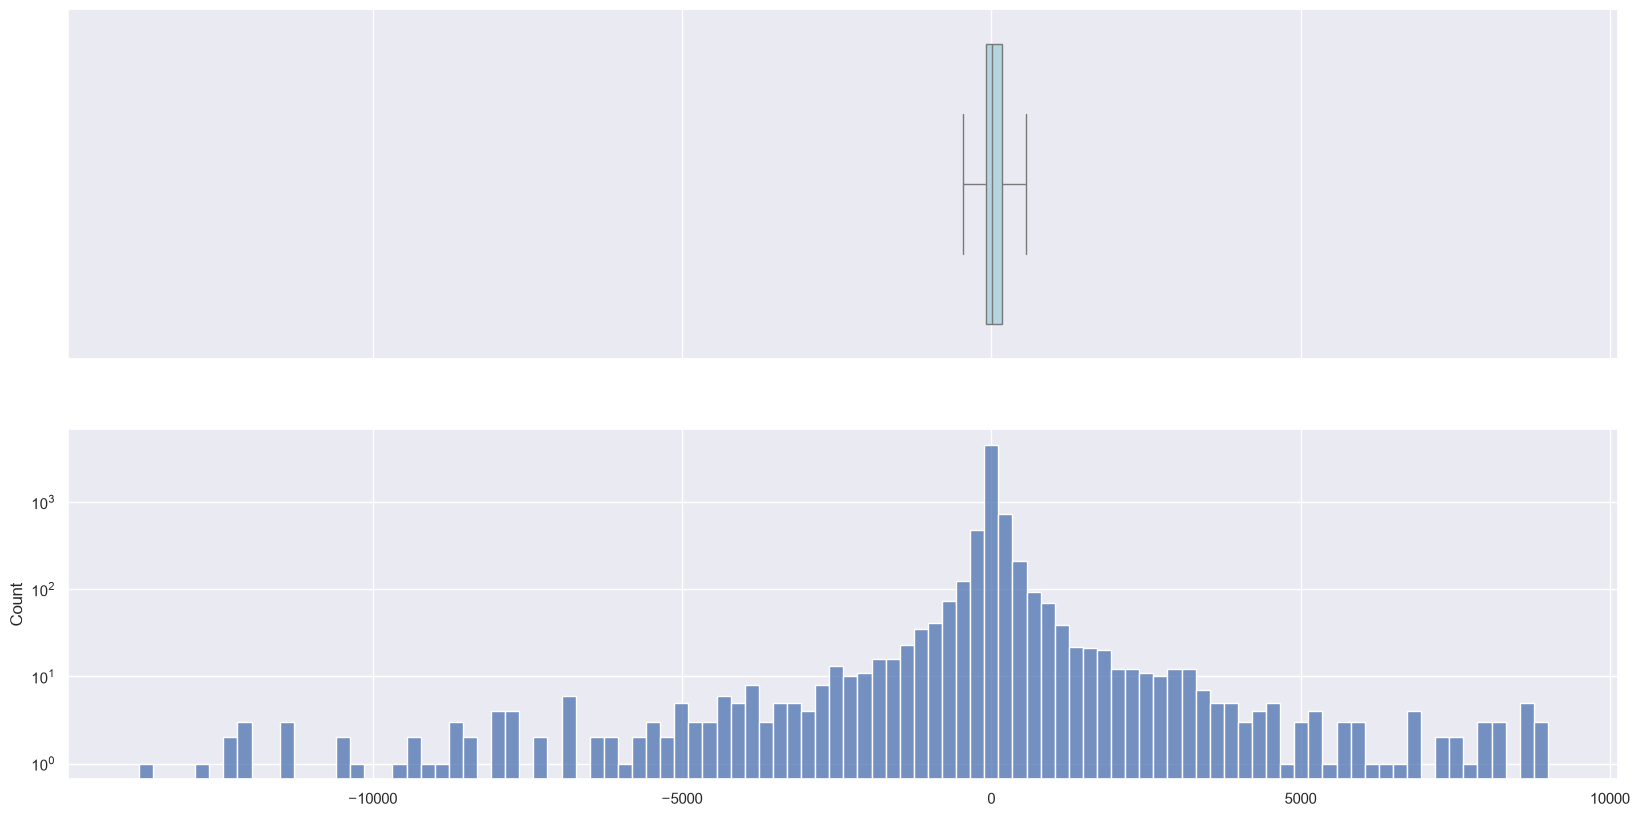

In [326]:
sns.set_theme(style="darkgrid")

fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(20, 10), sharex=True)

filtered_data1 = slise(gen_diff(df_pivot, start_year=2025, end_year=2024))

plt.yscale('log')

sns.histplot(
    x=filtered_data1,
    bins=100,
    ax=ax[1],
)

sns.boxplot(
    x=gen_diff(df_pivot, start_year=2024, end_year=2022),
    color='lightblue',
    showfliers=False,
    ax=ax[0],
)

In [282]:
top_500 = results_df[results_df['year'] == 2025].nlargest(500, 'revenue')

top_500_inns = top_500['inn'].tolist()

In [286]:
logging.basicConfig(level=logging.INFO, format='%(levelname)s: %(message)s', force=True)
ua = UserAgent()

async def fetch_revenue(session, inn, semaphore):
    url = f"https://bo.nalog.gov.ru/advanced-search/organizations/search?query={inn}&page=0"

    async with semaphore:
        await asyncio.sleep(random.uniform(0.5, 1.5))

        headers = {
            "User-Agent": ua.random,
            "Accept": "application/json, text/plain, */*",
            "Accept-Language": "ru-RU,ru;q=0.9",
            "Referer": "https://bo.nalog.gov.ru/"
        }

        try:
            async with session.get(url, headers=headers, ssl=False) as resp:
                if resp.status == 429:
                    logging.warning("Слишком много запросов")
                    return {"inn": inn, "status": "Слишком много запросов"}
                if resp.status != 200:
                    return {"inn": inn, "status": resp.status}

                company = await resp.json()
                if not company.get("content"):
                    return {"inn": inn, "status": "Компания не найдена"}

                org_region = company["content"][0].get("region")
                org_street = company["content"][0].get("street")
                org_house = company["content"][0].get("house")
                org_city = company["content"][0].get("city")

                org_act_city = org_city if not pd.isna(org_city) else org_region

                org_address = org_act_city + " " + org_street + " " + org_house

                return {'inn': inn, 'status': 'OK', 'address': org_address}

        except Exception as e:
            return {"inn": inn, "status": f"Ошибка: {e}"}

In [287]:
results = []

semaphore = asyncio.Semaphore(5)

async with aiohttp.ClientSession() as session:
    tasks = [fetch_revenue(session, inn, semaphore) for inn in top_500_inns]

    for i, res in enumerate(asyncio.as_completed(tasks)):
        result = await res
        results.append(result)
        if (i + 1) % 100 == 0:
            logging.info(f"Обработано {i + 1} из {len(top_500_inns)}...")

results_df = pd.DataFrame(results)
results_df.to_csv("top_500_address.csv", index=False, encoding="utf-8-sig")
logging.info("Готово! Данные сохранены")

INFO: Обработано 100 из 8927...
INFO: Обработано 200 из 8927...
INFO: Обработано 300 из 8927...
INFO: Обработано 400 из 8927...
INFO: Обработано 500 из 8927...
INFO: Готово! Данные сохранены


In [288]:
results_df['status'].value_counts()

status
OK                                                          490
Ошибка: can only concatenate str (not "NoneType") to str     10
Name: count, dtype: int64

In [295]:
import ssl
import certifi

ctx = ssl.create_default_context(cafile=certifi.where())

geolocator = Nominatim(
    user_agent='ivanovo_moscow',
    timeout=10,
    ssl_context=ctx
)

geocode = RateLimiter(geolocator.geocode, min_delay_seconds=1)

logging.info('Идет геокодирование')

results_df['location'] = results_df['address'].apply(geocode)

INFO: Идет геокодирование


In [302]:
results_df.to_csv("top_500_address_with_location.csv", index=False, encoding="utf-8-sig")

In [305]:
results_df['point'] = results_df['location'].apply(lambda loc: tuple(loc.point) if loc else None)
df = results_df.dropna(subset=['point'])

df['lat'] = df['point'].apply(lambda x: x[0])
df['lon'] = df['point'].apply(lambda x: x[1])

gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df.lon, df.lat),
    crs="EPSG:4326"
)

In [309]:
interactive_map = gdf.explore(
    marker_kwds={'radius': 6, 'color': 'red', 'fill': True},
    tooltip="address",
    tiles="CartoDB positron"
)

interactive_map.save("address_map.html")

Я нашел топ 500 компаний по чистой прибыли за 2025 год и нанес их на карту по месту регистрации. Карта сохранена в файле address_map.html

In [320]:
df = results_df[(results_df['revenue'] > 0) & (~results_df['cogs'].isna()) & (~results_df['comm_exp'].isna()) & (~results_df['mgmt_exp'].isna()) & (~results_df['net_profit'].isna())].copy()

df['cogs_pct'] = (df['cogs'] / df['revenue']) * -100
df['comm_exp_pct'] = (df['comm_exp'] / df['revenue']) * -100
df['mgmt_exp_pct'] = (df['mgmt_exp'] / df['revenue']) * -100

df['net_profit_pct'] = (df['net_profit'] / df['revenue']) * 100

df_2023 = df[df['year'] == 2023]

market_median = {
    "Выручка": 100.0,
    "Себестоимость": df_2023['cogs_pct'].median(),
    "Коммерческие": df_2023['comm_exp_pct'].median(),
    "Управленческие": df_2023['mgmt_exp_pct'].median(),
    "Прочие расходы/доходы": 0,
    "Чистая прибыль": df_2023['net_profit_pct'].median()
}

market_median["Прочие расходы/доходы"] = market_median["Чистая прибыль"] - (
    100 + market_median["Себестоимость"] + market_median["Коммерческие"] + market_median["Управленческие"]
)

In [321]:
import plotly.graph_objects as go

fig = go.Figure(go.Waterfall(
    name="Воронка P&L",
    orientation="v",
    measure=["relative", "relative", "relative", "relative", "relative", "total"],
    x=["Выручка", "Себестоимость", "Коммерческие", "Управленческие", "Прочее (налоги, %)", "Чистая прибыль"],

    y=[
        market_median["Выручка"],
        market_median["Себестоимость"],
        market_median["Коммерческие"],
        market_median["Управленческие"],
        market_median["Прочие расходы/доходы"],
        market_median["Чистая прибыль"]
    ],

    textposition="outside",
    text=[f"{v:.1f}%" for v in [
        market_median["Выручка"], market_median["Себестоимость"],
        market_median["Коммерческие"], market_median["Управленческие"],
        market_median["Прочие расходы/доходы"], market_median["Чистая прибыль"]
    ]],

    decreasing={"marker": {"color": "#ef553b"}},
    increasing={"marker": {"color": "#00cc96"}},
    totals={"marker": {"color": "#636efa"}}
))

fig.update_layout(
    title="Воронка преобразования выручки в чистую прибыль за 2023 год",
    plot_bgcolor="white",
    showlegend=False,
    margin=dict(t=80, b=40, l=40, r=40),
    waterfallgap=0.3
)

fig.show()

Дополнительно я посроил воронку преобразования выручки в чистую прибыль за 2023 год. На ней видно, куда уходит большая часть средств от выручки (себестоимость) и как выручка поэтапно преобразуется в чистую прибыль. Как видно из 100% средств в среднем остается только 1.8% чистой прибыли.